In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dense, Flatten,
                                      Dropout, BatchNormalization,
                                      GlobalAveragePooling2D, Input)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
# 1(i) Load Dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("=== Dataset Shape ===")
print(f"Training images : {x_train.shape}")
print(f"Training labels : {y_train.shape}")
print(f"Test images     : {x_test.shape}")
print(f"Test labels     : {y_test.shape}")
print(f"Pixel value range: {x_train.min()} – {x_train.max()}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 67s 0us/step
=== Dataset Shape ===
Training images : (50000, 32, 32, 3)
Training labels : (50000, 1)
Test images     : (10000, 32, 32, 3)
Test labels     : (10000, 1)
Pixel value range: 0 – 255


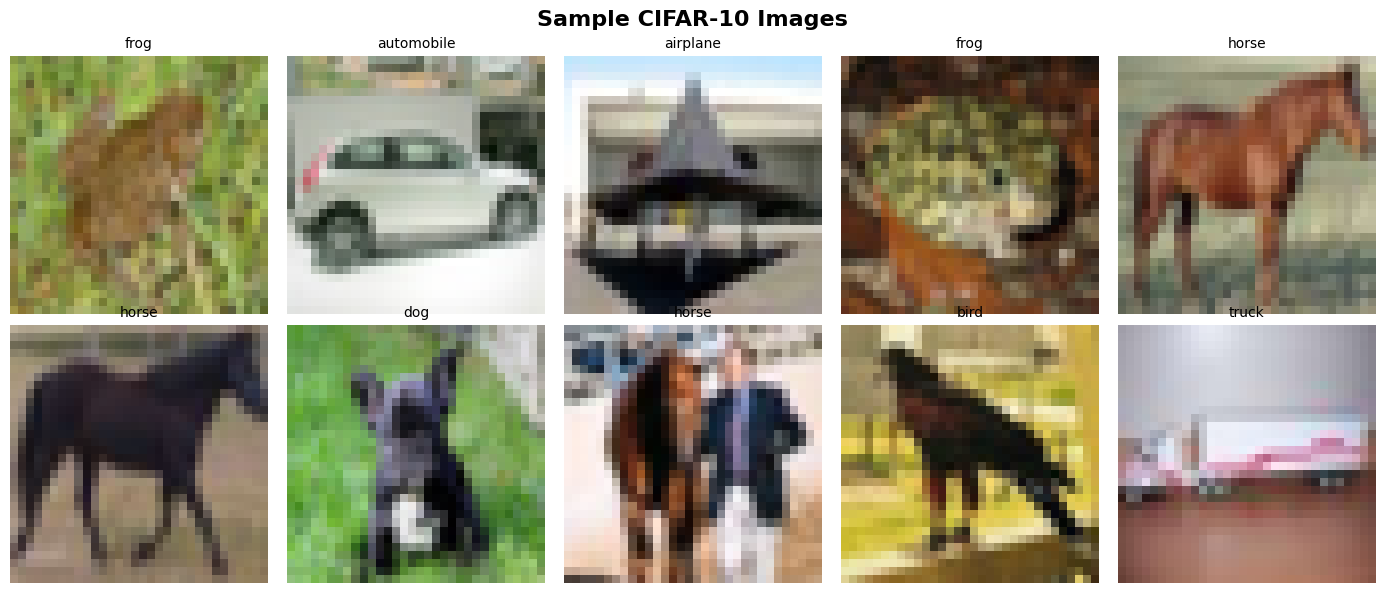

In [5]:
# Display sample images with labels
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Sample CIFAR-10 Images', fontsize=16, fontweight='bold')
indices = np.random.choice(len(x_train), 10, replace=False)
for ax, idx in zip(axes.flat, indices):
    ax.imshow(x_train[idx])
    ax.set_title(class_names[y_train[idx][0]], fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

Number of classes: 10

Class             Train     Test
----------------------------------
airplane           5000     1000
automobile         5000     1000
bird               5000     1000
cat                5000     1000
deer               5000     1000
dog                5000     1000
frog               5000     1000
horse              5000     1000
ship               5000     1000
truck              5000     1000


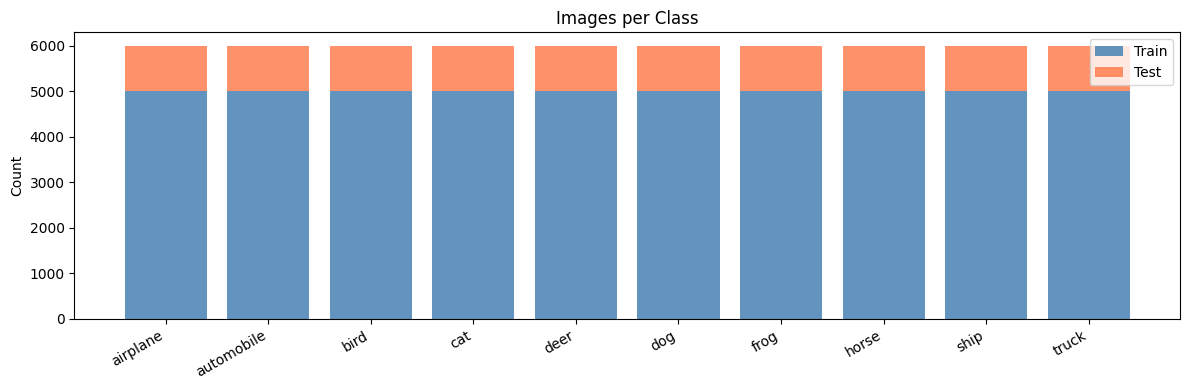

In [6]:
# 1(ii) Data Exploration
from collections import Counter

print(f"Number of classes: {len(class_names)}")
train_counts = Counter(y_train.flatten())
test_counts  = Counter(y_test.flatten())

print(f"\n{'Class':<14} {'Train':>8} {'Test':>8}")
print("-" * 34)
for i, name in enumerate(class_names):
    print(f"{name:<14} {train_counts[i]:>8} {test_counts[i]:>8}")

# Bar chart
x = np.arange(len(class_names))
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x, [train_counts[i] for i in range(10)], color='steelblue', alpha=0.85, label='Train')
ax.bar(x, [test_counts[i]  for i in range(10)], color='coral', alpha=0.85, label='Test',
       bottom=[train_counts[i] for i in range(10)])
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_ylabel('Count'); ax.set_title('Images per Class'); ax.legend()
plt.tight_layout(); plt.show()

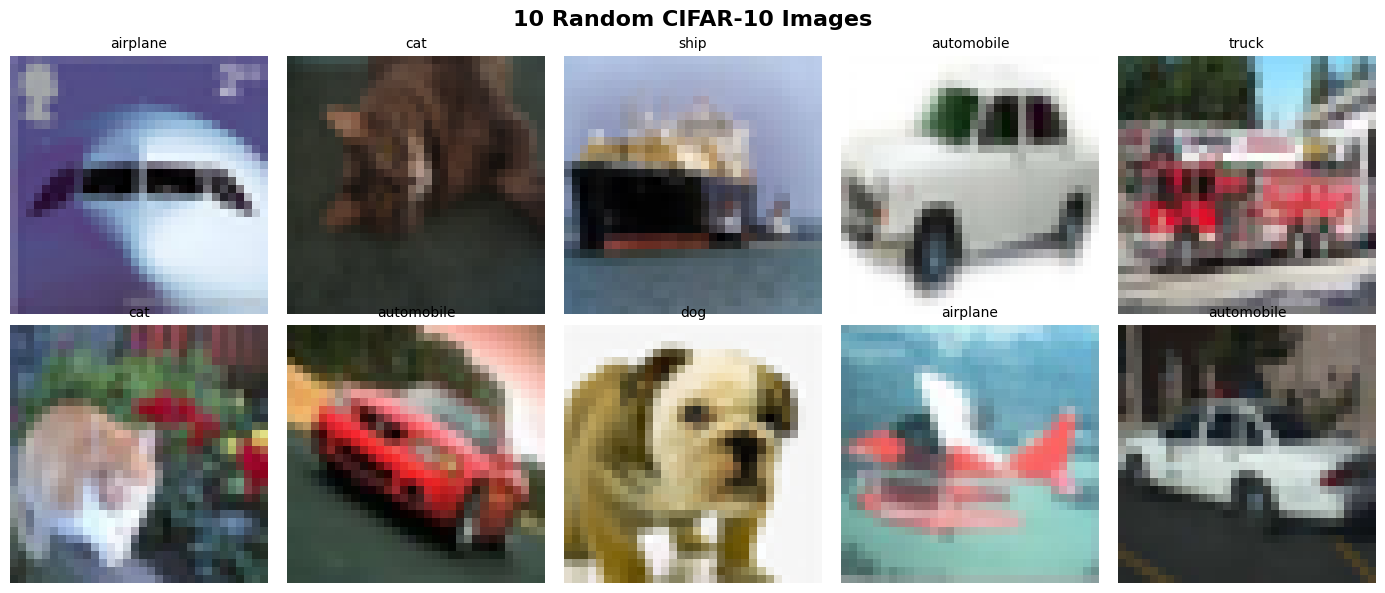

In [7]:
# Visualize 10 random images
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('10 Random CIFAR-10 Images', fontsize=16, fontweight='bold')
for ax in axes.flat:
    idx = np.random.randint(len(x_train))
    ax.imshow(x_train[idx])
    ax.set_title(class_names[y_train[idx][0]], fontsize=10)
    ax.axis('off')
plt.tight_layout(); plt.show()

In [8]:
# 2(i) Normalize pixel values to [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

print(f"Before: min={x_train.min()}, max={x_train.max()}")
print(f"After : min={x_train_norm.min():.4f}, max={x_train_norm.max():.4f}")

Before: min=0, max=255
After : min=0.0000, max=1.0000


ImageDataGenerator configured with rotation, flip, zoom, shift.


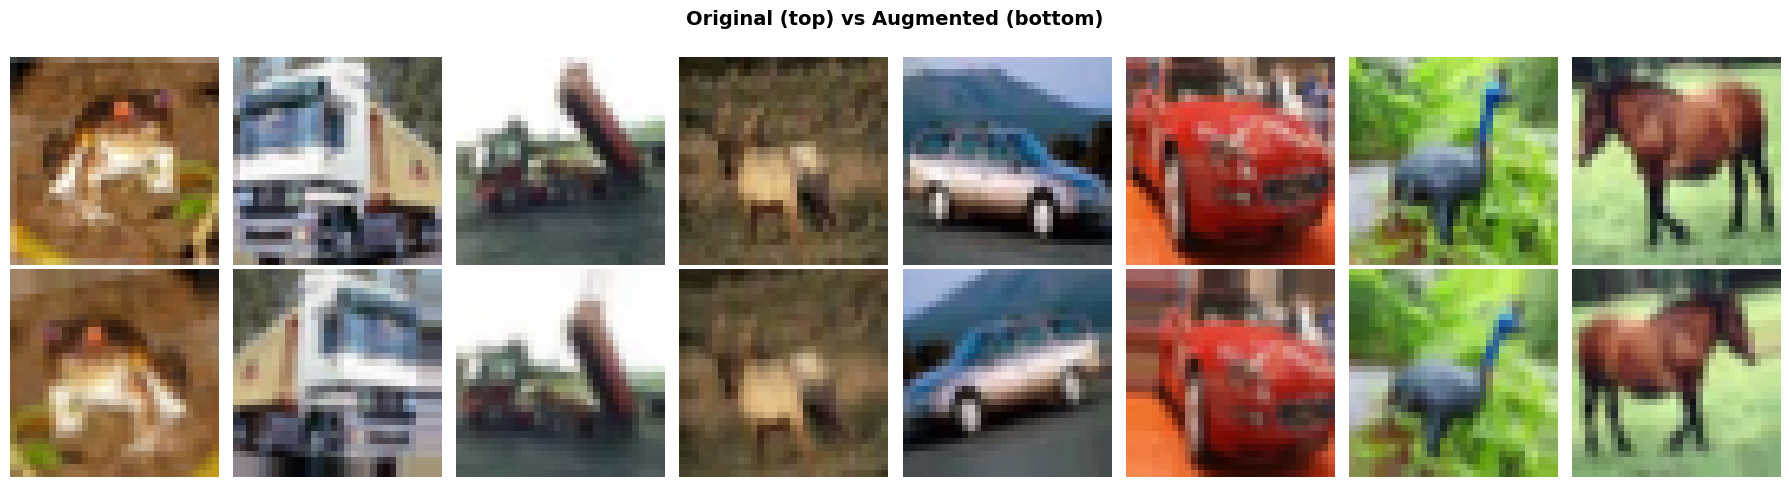

In [10]:
# 2(iii) Data Augmentation — at least 2 techniques
datagen = ImageDataGenerator(
    rotation_range=15,       # Technique 1: Rotation ±15°
    horizontal_flip=True,    # Technique 2: Horizontal flip
    zoom_range=0.1,          # Technique 3: Zoom ±10%
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(x_train_norm)
print("ImageDataGenerator configured with rotation, flip, zoom, shift.")

# Visualize augmented samples
sample_imgs = x_train_norm[:8]
aug_imgs    = next(datagen.flow(sample_imgs, batch_size=8, shuffle=False))

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle('Original (top) vs Augmented (bottom)', fontsize=14, fontweight='bold')
for i in range(8):
    axes[0, i].imshow(sample_imgs[i]);                axes[0, i].axis('off')
    axes[1, i].imshow(np.clip(aug_imgs[i], 0, 1));    axes[1, i].axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# 3(i) Baseline CNN 
def build_baseline_cnn():
    model = Sequential([
        # LAyer 1
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        BatchNormalization(),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.25),
        # Layer 2
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.25),
        # Layer 3
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),
        # Classifier
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ], name='Baseline_CNN')
    return model

baseline_model = build_baseline_cnn()
baseline_model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,458 (2.55 MB)

 Trainable params: 667,498 (2.55 MB)

 Non-trainable params: 960 (3.75 KB)

In [15]:
# Train Baseline CNN
callbacks_b = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
]

history_baseline = baseline_model.fit(
    datagen.flow(x_train_norm, y_train_cat, batch_size=64),
    steps_per_epoch=len(x_train_norm) // 64,
    epochs=30,
    validation_data=(x_test_norm, y_test_cat),
    callbacks=callbacks_b,
    verbose=1
)

Epoch 1/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 97s 124ms/step - accuracy: 0.7390 - loss: 0.7544 - val_accuracy: 0.7615 - val_loss: 0.7028 - learning_rate: 0.0010
Epoch 2/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6719 - loss: 0.8139 - val_accuracy: 0.7606 - val_loss: 0.7032 - learning_rate: 0.0010
Epoch 3/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 73s 93ms/step - accuracy: 0.7505 - loss: 0.7268 - val_accuracy: 0.7609 - val_loss: 0.7105 - learning_rate: 0.0010
Epoch 4/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7969 - loss: 0.6461 - val_accuracy: 0.7649 - val_loss: 0.7004 - learning_rate: 0.0010
Epoch 5/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.7510 - loss: 0.7164 - val_accuracy: 0.7512 - val_loss: 0.7310 - learning_rate: 0.0010
Epoch 6/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7188 - loss: 0.9681 - val_accuracy: 0.7363 - val_loss: 0.7799 - learning_rate: 0.0010
Epoch 7/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 116s 148ms/step - accuracy: 0.7565 - los

In [16]:
# 3(ii) Transfer Learning — MobileNetV2
def build_transfer_model():
    inputs    = Input(shape=(32, 32, 3))
    x         = tf.keras.layers.Resizing(96, 96)(inputs)   # upscale for MobileNetV2

    base      = MobileNetV2(input_shape=(96, 96, 3),
                             include_top=False,
                             weights='imagenet')
    base.trainable = False                                  # Freeze all conv layers
    print(f"Frozen layers: {len(base.layers)}")

    x         = base(x, training=False)
    x         = GlobalAveragePooling2D()(x)
    x         = Dense(256, activation='relu')(x)
    x         = Dropout(0.4)(x)
    outputs   = Dense(10, activation='softmax')(x)

    return Model(inputs, outputs, name='MobileNetV2_Transfer')

transfer_model = build_transfer_model()
transfer_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])
transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 28s 3us/step
Frozen layers: 154


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
# Train Transfer Model
callbacks_t = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
]

datagen_t = ImageDataGenerator(rotation_range=15, horizontal_flip=True,
                                zoom_range=0.1, width_shift_range=0.1,
                                height_shift_range=0.1)
datagen_t.fit(x_train_norm)

history_transfer = transfer_model.fit(
    datagen_t.flow(x_train_norm, y_train_cat, batch_size=64),
    steps_per_epoch=len(x_train_norm) // 64,
    epochs=30,
    validation_data=(x_test_norm, y_test_cat),
    callbacks=callbacks_t,
    verbose=1
)

Epoch 1/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 161s 203ms/step - accuracy: 0.6165 - loss: 1.0970 - val_accuracy: 0.7327 - val_loss: 0.7785 - learning_rate: 0.0010
Epoch 2/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 46s 58ms/step - accuracy: 0.6562 - loss: 0.8985 - val_accuracy: 0.7329 - val_loss: 0.7790 - learning_rate: 0.0010
Epoch 3/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 275s 352ms/step - accuracy: 0.6715 - loss: 0.9397 - val_accuracy: 0.7685 - val_loss: 0.6654 - learning_rate: 0.0010
Epoch 4/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 82s 105ms/step - accuracy: 0.7031 - loss: 0.8161 - val_accuracy: 0.7695 - val_loss: 0.6649 - learning_rate: 0.0010
Epoch 5/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 152s 195ms/step - accuracy: 0.6894 - loss: 0.8883 - val_accuracy: 0.7508 - val_loss: 0.7157 - learning_rate: 0.0010
Epoch 6/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.7500 - loss: 0.7417 - val_accuracy: 0.7506 - val_loss: 0.7197 - learning_rate: 0.0010
Epoch 7/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 157s 202ms/step - accuracy: 0

In [26]:
# Accuracy & Loss
baseline_loss, baseline_acc = baseline_model.evaluate(x_test_norm, y_test_cat, verbose=0)
transfer_loss, transfer_acc = transfer_model.evaluate(x_test_norm, y_test_cat, verbose=0)

print(f"{'Model':<25} {'Loss':>8} {'Accuracy':>10}")

print(f"{'Baseline CNN':<25} {baseline_loss:>8.4f} {baseline_acc*100:>9.2f}%")
print(f"{'MobileNetV2 Transfer':<25} {transfer_loss:>8.4f} {transfer_acc*100:>9.2f}%")

Model                         Loss   Accuracy
Baseline CNN                0.5019     82.97%
MobileNetV2 Transfer        0.5607     81.41%


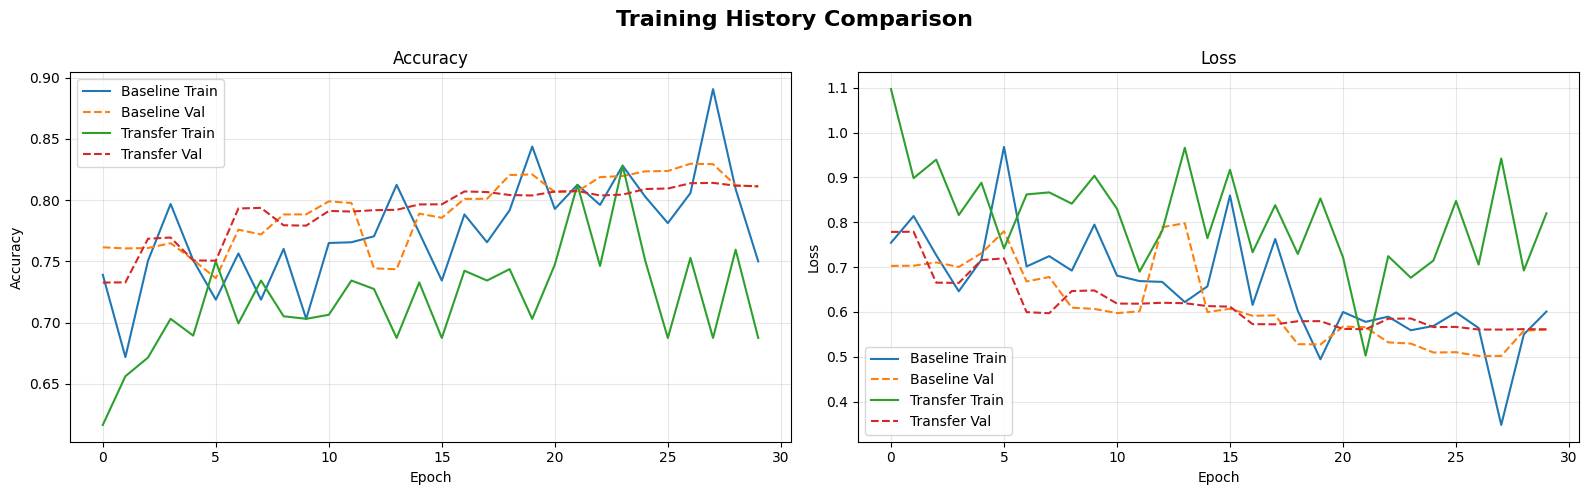

In [19]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Training History Comparison', fontsize=16, fontweight='bold')

for ax, metric, title in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
    ax.plot(history_baseline.history[metric],            label='Baseline Train')
    ax.plot(history_baseline.history[f'val_{metric}'], '--', label='Baseline Val')
    ax.plot(history_transfer.history[metric],            label='Transfer Train')
    ax.plot(history_transfer.history[f'val_{metric}'], '--', label='Transfer Val')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(title)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

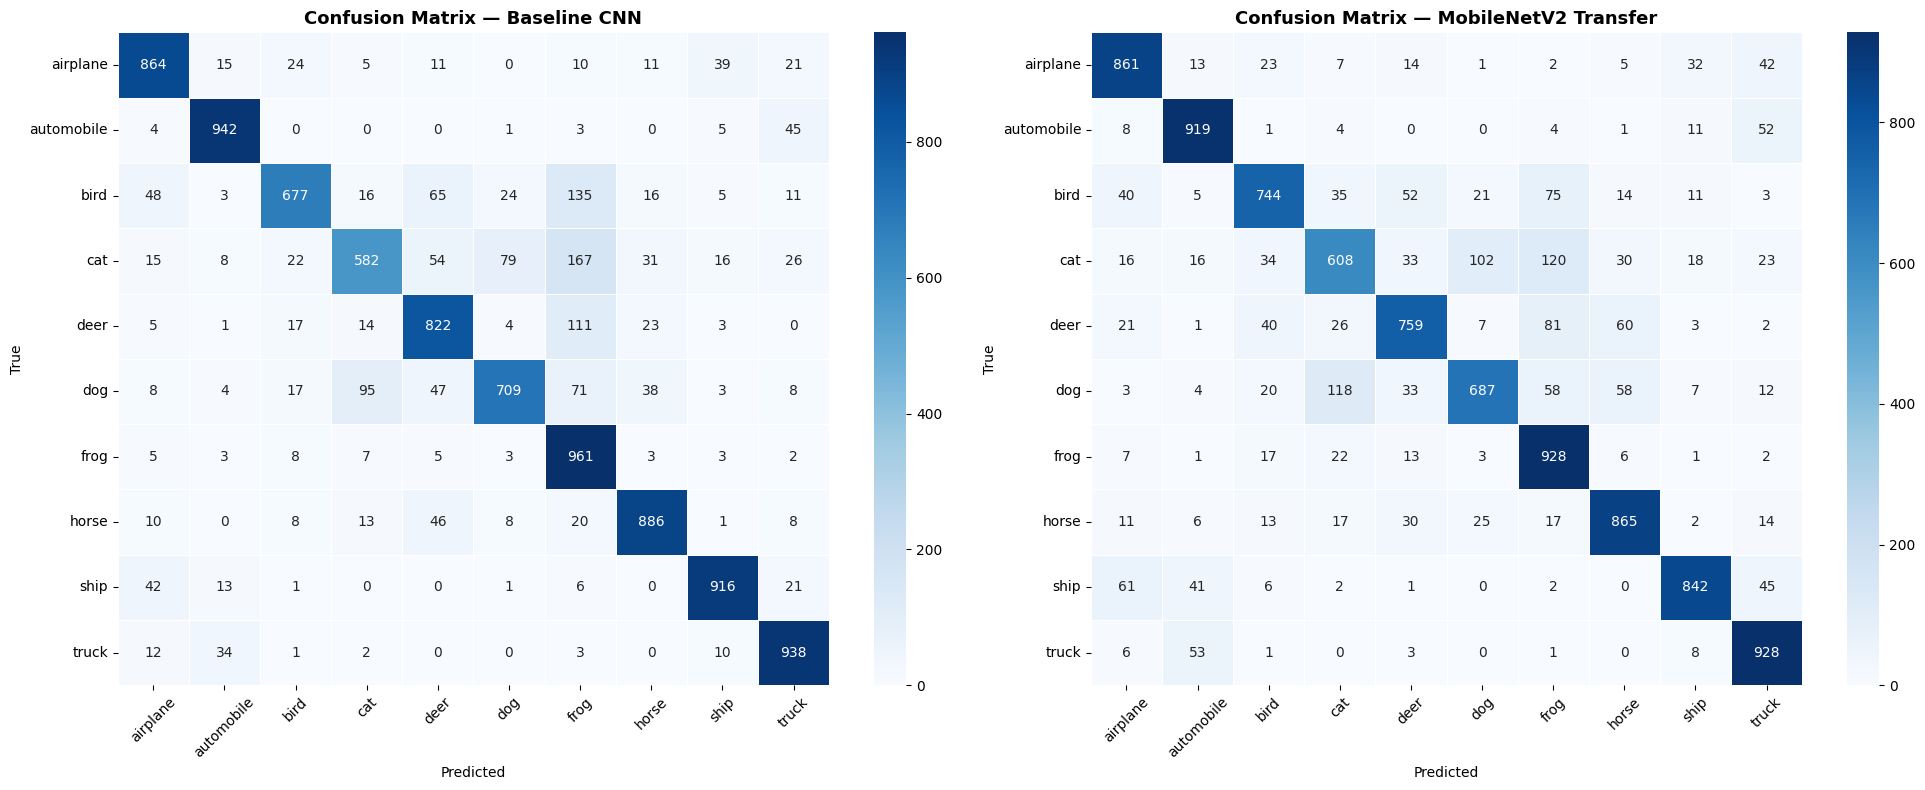

In [20]:
# Confusion Matrices
def plot_cm(model, title, ax):
    y_pred = np.argmax(model.predict(x_test_norm, verbose=0), axis=1)
    y_true = y_test.flatten()
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)
    return y_pred, y_true

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
y_pred_b, y_true = plot_cm(baseline_model, 'Confusion Matrix — Baseline CNN',         axes[0])
y_pred_t, _      = plot_cm(transfer_model, 'Confusion Matrix — MobileNetV2 Transfer', axes[1])
plt.tight_layout(); plt.show()

In [25]:
# Classification Reports

print("Classification Report — Baseline CNN")
print(classification_report(y_true, y_pred_b, target_names=class_names))


print("Classification Report — MobileNetV2 Transfer Learning")
print(classification_report(y_true, y_pred_t, target_names=class_names))

Classification Report — Baseline CNN
              precision    recall  f1-score   support

    airplane       0.85      0.86      0.86      1000
  automobile       0.92      0.94      0.93      1000
        bird       0.87      0.68      0.76      1000
         cat       0.79      0.58      0.67      1000
        deer       0.78      0.82      0.80      1000
         dog       0.86      0.71      0.78      1000
        frog       0.65      0.96      0.77      1000
       horse       0.88      0.89      0.88      1000
        ship       0.92      0.92      0.92      1000
       truck       0.87      0.94      0.90      1000

    accuracy                           0.83     10000
   macro avg       0.84      0.83      0.83     10000
weighted avg       0.84      0.83      0.83     10000

Classification Report — MobileNetV2 Transfer Learning
              precision    recall  f1-score   support

    airplane       0.83      0.86      0.85      1000
  automobile       0.87      0.92      0.

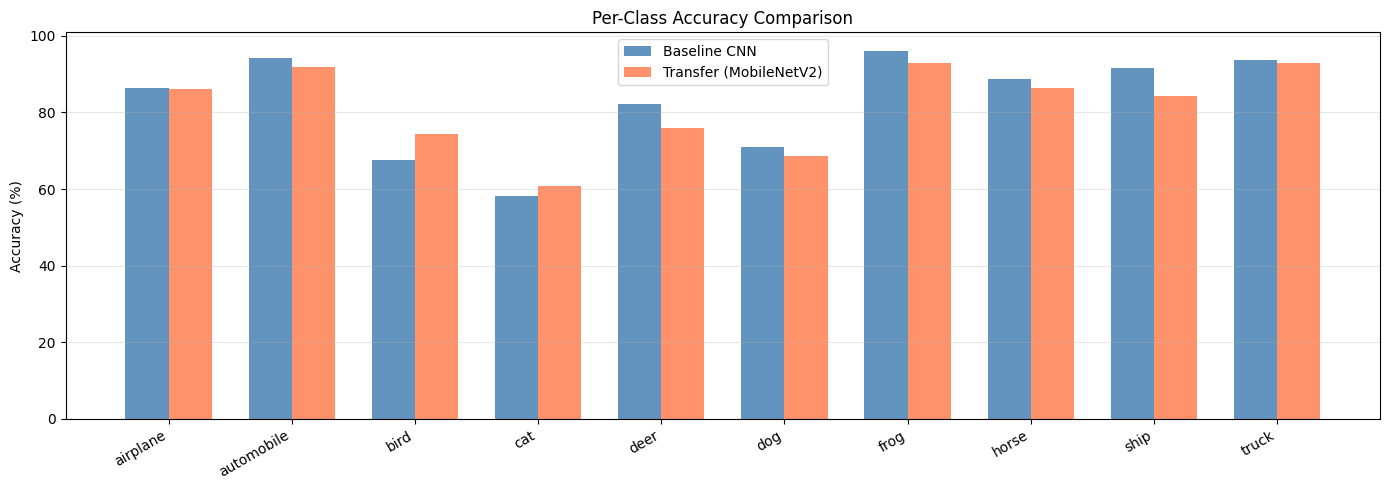

In [22]:
# Per-class accuracy comparison
def per_class_acc(y_true, y_pred):
    return [(y_pred[y_true == i] == i).mean() * 100 for i in range(10)]

acc_b = per_class_acc(y_true, y_pred_b)
acc_t = per_class_acc(y_true, y_pred_t)

x_pos = np.arange(10); w = 0.35
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x_pos - w/2, acc_b, w, label='Baseline CNN',        color='steelblue', alpha=0.85)
ax.bar(x_pos + w/2, acc_t, w, label='Transfer (MobileNetV2)', color='coral', alpha=0.85)
ax.set_xticks(x_pos); ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_ylabel('Accuracy (%)'); ax.set_title('Per-Class Accuracy Comparison')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:

#Interpretation & Reflection


#5(i) HOW PRETRAINED CNNs EXTRACT USEFUL FEATURES
#CNNs learn a hierarchical feature representation:

  #Early layers - Edges, colours, gradients   
  #Middle layers - Textures, patterns, shapes      
  #Late layers - Object parts, high-level concepts 

#MobileNetV2 trained on about a million ImageNet images has already learned
#these universal visual features. By freezing the backbone and
#training only a small Dense head on CIFAR-10, we reuse this
#knowledge without re-learning it, it is called Feature Extraction.

#1. Why is transfer learning useful for small datasets?
#- Deep CNNs have millions of parameters; 5000 samples/class is
 # too small to train them from scratch without overfitting.
-# Pretrained weights encode general visual knowledge, so only
  #the lightweight head (few thousand params) needs learning.
#- The frozen backbone acts as a strong regulariser.
#- Convergence is faster — features are already near-optimal.

###2. What happens if pretrained layers are NOT frozen?
#- High learning rates destroy carefully learned ImageNet
 # features — known as CATASTROPHIC FORGETTING.
-# Noisy gradients from small data cause large, harmful updates
  #deep in the network, overwriting useful generic representations.
#- The model may converge to a WORSE solution than scratch.
#- Correct approach: freeze → train head → optionally fine-tune
 # top blocks with a very small lr (e.g. 1e-5).

#3. When can transfer learning perform WORSE than scratch?
#1. Large domain mismatch (X-rays, satellite images, microscopy).
#2. Target dataset is very large — task-specific features win.
#3. Very different input distributions (e.g. 32×32 vs 224×224
# causes upsampling artefacts frozen layers weren't trained on).
#4. Wrong fine-tuning strategy — unfreezing all layers + high lr.
#5. Task requires non-visual features (audio, time-series, etc.).


In [24]:
# Final Summary
delta = (transfer_acc - baseline_acc) * 100
sign  = '+' if delta >= 0 else ''

print("FINAL RESULTS SUMMARY")
print(f"{'Metric':<30} {'Baseline':>10} {'Transfer':>10}")
print(f"{'Test Accuracy':<30} {baseline_acc*100:>9.2f}% {transfer_acc*100:>9.2f}%")
print(f"{'Test Loss':<30} {baseline_loss:>10.4f} {transfer_loss:>10.4f}")
print(f"{'Improvement':<30} {sign}{delta:.2f}%")


FINAL RESULTS SUMMARY
Metric                           Baseline   Transfer
Test Accuracy                      82.97%     81.41%
Test Loss                          0.5019     0.5607
Improvement                    -1.56%
